In [149]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
from collections import OrderedDict

In [150]:
script_dir = os.path.dirname(os.path.abspath(''))
fundus_path = os.path.join(script_dir, "Assignment_2/Data/Fundus image/");
vessel_path = os.path.join(script_dir, "Assignment_2/Data/Blood vessels/");
data_path = os.path.join(script_dir, "Assignment_2/Data/");

output_path = os.path.join(script_dir, "Assignment_2/Output/");

In [151]:
def createImage(shape):
    img = np.full((shape[0], shape[1]),0,dtype='uint8')
    print(img.shape)
    return img

def create3ChImage(shape):
    img = np.full((shape[0],shape[1],3),0,dtype='uint8')
    return img

def showImage(image):
    image = np.copy(image)
    print(image.shape)
    # cv.imshow('myImage', image)
    # cv.waitKey()
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.show()
    return

def monoTone(image):
    image = np.copy(image)
    max = np.max(image)
    ret,thresh = cv.threshold(image,max-30,255,0);
    return thresh;


def createBorders(image,border_size):
    print(image)
    padded = np.pad(image,pad_width=border_size)
    #print(padded.shape)
    return padded

def createBordersWhite(image,border_size):
    padded = np.pad(image,pad_width=border_size,mode="constant",constant_values = 255)
    return padded

def pad_image(image, pad_height, pad_width):
    height, width, channels = image.shape
    padded_image = np.zeros((height + 2 * pad_height, width + 2 * pad_width, channels), dtype=np.uint8)
    padded_image[pad_height:pad_height+height, pad_width:pad_width+width, :] = image
    return padded_image

def remove_border(image, border_size):
    image = np.copy(image)
    height, width = image.shape[:2] 
    cropped_image = image[border_size:height-border_size, border_size:width-border_size]
    return cropped_image


In [152]:
def plot(data,isSave,name):
    width = 0.8
    labels = np.arange(256)
    plt.figure(figsize=(10,3))
    plt.bar(labels,data, width)
    if isSave: plt.savefig(name+".png")
    #plt.show()


def calculateHistogram(image,isShow):
    data = np.zeros(256);
    for x in image: 
        for y in x:
            data[y]+= 1;
    if isShow: plot(data,True,"Figure_6")
    return data
    
def globalEnhanceImage(image):
    image = np.copy(image)
    r_min = image.min()
    r_max = image.max()
    
    image = (((image - r_min)/(r_max - r_min)) * (255-0)).astype("uint8");

    return image;

def constransStretching(image,isShow):
    image_ = np.copy(image)
    stretched_image = np.copy(image_)
    
    lower_percentile = np.percentile(image,5)
    higher_percentile = np.percentile(image,95)
    stretched_image = (((stretched_image - lower_percentile)/(higher_percentile - lower_percentile)) * (255-0)).astype("uint8")
    stretched_image[image_ <= lower_percentile] = 0
    stretched_image[image_ >= higher_percentile] = 255
    return stretched_image

def calculatePDF(hist,shape,isShow):
    area = shape[0]*shape[1]
    pdf = hist/area
    if isShow: plot(pdf,True,"Figure_2")
    return pdf

def calculateCDF(pdf,isShow):
    cdf = np.zeros(256)
    current = 0
    for i in range(255): 
        current += pdf[i]
        cdf[i] = current
        
    if isShow: plot(cdf,True,"Figure_3")
    return cdf

def scaleCDF(cdf,isShow):
    cdf = cdf*255
    if isShow: plot(cdf,True,"Figure_4")
    return cdf.astype("uint8")

def equalizeHistogram(image,cdf):
    image = np.copy(image)
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            image[x,y] = cdf[image[x,y]]
    return image



def equalizeImageGlobal(image,isShow):
    hist = calculateHistogram(image,isShow=isShow)
    pdf = calculatePDF(hist,image.shape,isShow=isShow)
    cdf = calculateCDF(pdf,isShow=isShow)
    cdf_scaled = scaleCDF(cdf,isShow=isShow)
    image_eq = equalizeHistogram(image,cdf_scaled)
    hist_eq = calculateHistogram(image_eq,isShow=isShow)
    return image_eq,hist_eq

def equalizeImageLocal(image,kernel):
    image = createBorders(image,max(kernel))
    height,width = image.shape[:2]
    k_h,k_w = kernel[:2]
    if((k_h+1) % 2 != 0 or (k_w+1) % 2 != 0): 
        print("Error: Invalid Kernel! Please enter odd kernel.")
        exit()
    k_h = int((k_h-1)/2)
    k_w = int((k_w-1)/2)
    for x in range(k_h,height,1):
        for y in range(k_w,width,1):
            image[x-k_h:x+k_h,y-k_w:y+k_w],hist_eq = equalizeImageGlobal(image[x-k_h:x+k_h,y-k_w:y+k_w],False)
    return remove_border(image,max(kernel))

In [153]:
def nerves_intesities(image, mask):
    w,h = image.shape
    print(w, h)
    nerves = []
    for x in range(w):
        for y in range(h):
            if(mask[x,y] == 255):
                if(not image[x,y] in nerves):
                    nerves.append(image[x,y])
    nerves.sort()
    return nerves

In [154]:
def highlight_nerves(image, nerves_intesities):
    image = np.copy(image)
    w,h = image.shape
    print(w, h)
    for x in range(w):
        for y in range(h):
            if(image[x,y] in nerves_intesities):
                  image[x,y] = 255
            else:
                image[x,y] = 0
    return image

In [155]:
def minMaxFilter(image,kernel,isMin):
    height,width = image.shape[:2]
    image = createBorders(image,(max(kernel)))
    filtered_image = np.zeros_like(image)
    k_h,k_w = kernel[:2]
    if((k_h+1) % 2 != 0 or (k_w+1) % 2 != 0):
        print("Error: Invalid Kernel! Please enter odd kernel.")
        exit()
    k_h = int((k_h-1)/2)
    k_w = int((k_w-1)/2)
    for x in range(k_h,height,1):
        for y in range(k_w,width,1):
            img_selection = image[x-k_h:x+(k_h+1),y-k_w:y+(k_w+1)]
            filtered_image[x,y] = np.min(img_selection).astype(np.uint8) if isMin else np.max(img_selection).astype(np.uint8)
    return remove_border(filtered_image,(max(kernel)))

def medianFilter(image,kernel):
    height,width = image.shape[:2]
    image = createBorders(image,(max(kernel)//2))
    filtered_image = np.zeros_like(image)
    k_h,k_w = kernel[:2]
    if((k_h+1) % 2 != 0 or (k_w+1) % 2 != 0):
        print("Error: Invalid Kernel! Please enter odd kernel.")
        exit()
    k_h = int((k_h-1)/2)
    k_w = int((k_w-1)/2)
    for x in range(k_h,height,1):
        for y in range(k_w,width,1):
            img_selection = image[x-k_h:x+(k_h+1),y-k_w:y+(k_w+1)]
            filtered_image[x,y] = np.median(img_selection).astype(np.uint8)
    return remove_border(filtered_image,(max(kernel)))


In [156]:
def check_mask(image, mask,masks):
    
    for x in range(mask.shape[0]):
        for y in range(mask.shape[1]):
            if(mask[x,y] != 0):
                if(mask[x,y] in masks):
                        if image[x,y] not in masks[mask[x,y]]:
                            masks[mask[x,y]][image[x,y]] = 1
                        else:
                            masks[mask[x,y]][image[x,y]] += 1                   
                else:       
                    masks[mask[x,y]] = {};
                    masks[mask[x,y]][image[x,y]] = 1
    
    for x in masks.keys():
        values = list(masks[x].values())
        mean = np.mean(values)
        keys = []
        for key in masks[x].keys():
            keys.append(key)
        for i in keys:
                if(masks[x][i] < mean+mean/2):
                        masks[x].pop(i)
                        
                    
    return masks

In [157]:
def find_coord(image):
    max_value = np.max(image)
    for x in range(image.shape[0]):
        check = False
        for y in range(image.shape[1]):
            if(image[x,y] == max_value):
                check = True
                break
        if(check): return (x,y)

(2592, 3888, 3)


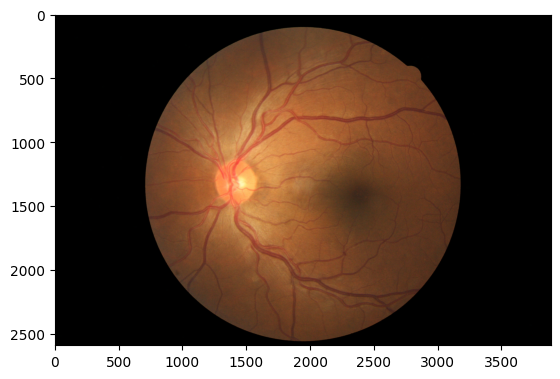

(2592, 3888)


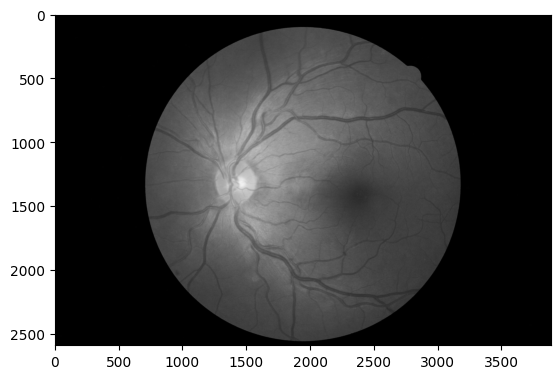

(2592, 3888)


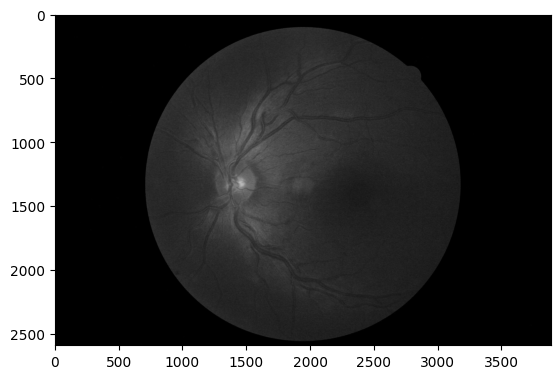

(2592, 3888)


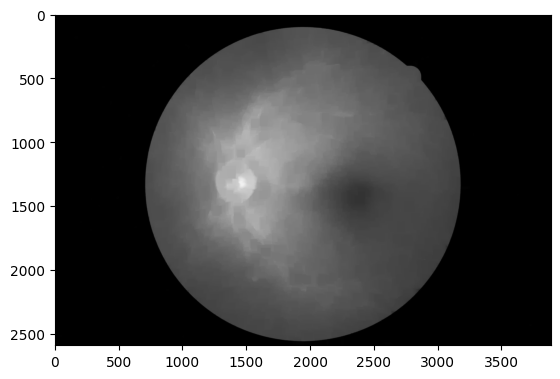

(2592, 3888)


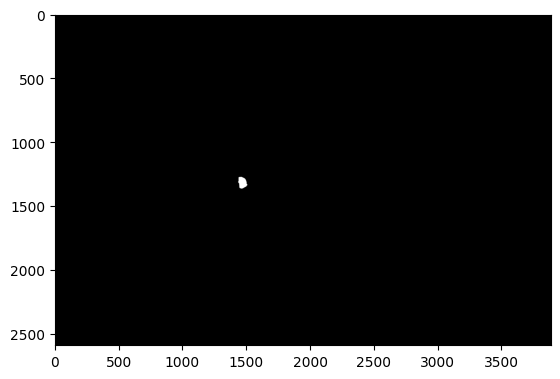

2


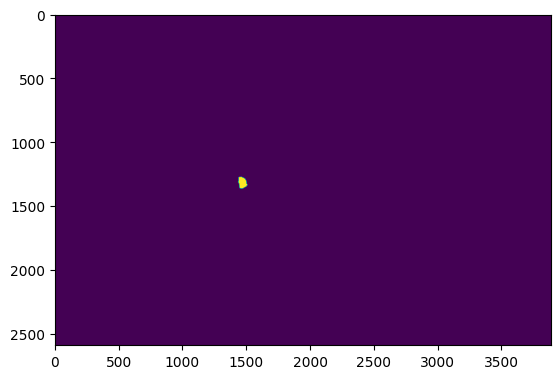

{1: 6716}
{1: 19}
73 92
(2592, 3888)


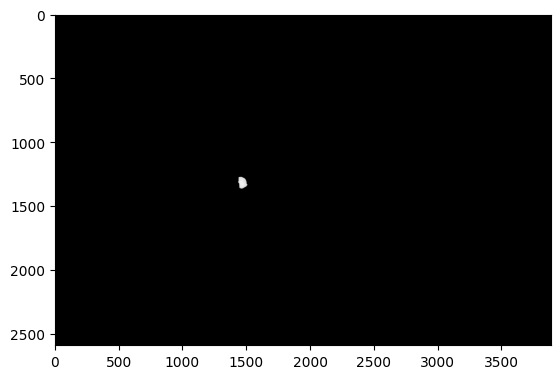

(2592, 3888)


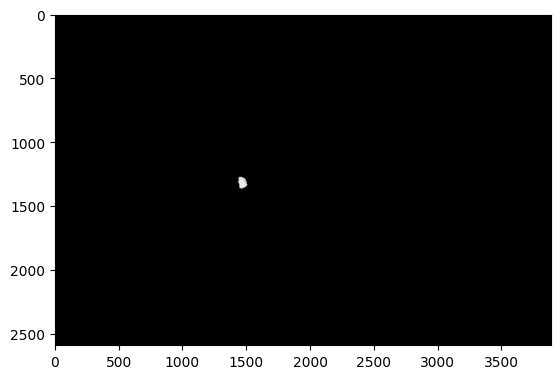

Found Coord
(1330, 1459)
Min Max Loc
(1459, 1330)
(2592, 3888, 3)


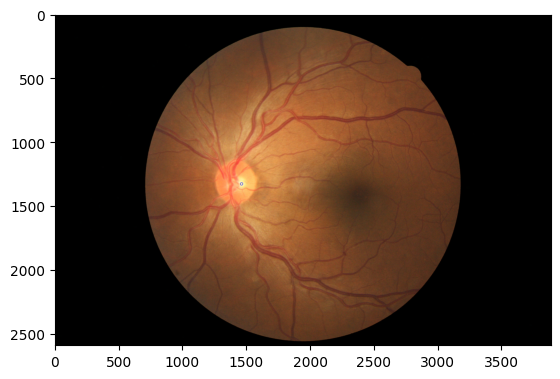

(584, 565)


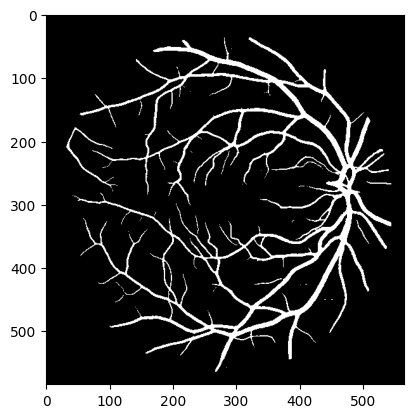

In [158]:
image = cv.imread(fundus_path+"17_left.jpeg", cv.IMREAD_COLOR)
showImage(image)

gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
showImage(gray_image)


channel = image[:, :, 0]
showImage(channel)

# channel,hist = equalizeImageGlobal(gray_image,False)
# showImage(channel)

gaussian = cv.GaussianBlur(gray_image,(3,3),0)


# define the kernel 
kernel = np.ones((27, 27), np.uint8) 
  
# opening the image 
closing = cv.morphologyEx(gaussian, cv.MORPH_CLOSE, kernel, iterations=2) 

showImage(closing)



mono = monoTone(closing)
showImage(mono)


connectivity = 8
# Perform the operation
output = cv.connectedComponentsWithStats(mono, connectivity, cv.CV_32S)
# Get the results
# The first cell is the number of labels
num_labels = output[0]
# The second cell is the label matrix
labels = output[1]
# The third cell is the stat matrix
stats = output[2]
print(num_labels)
plt.imshow(labels)
plt.show()

# The fourth cell is the centroid matrix
centroids = output[3]

array = {}
for i in range(num_labels):
    width = (stats[i,cv.CC_STAT_WIDTH])
    height = (stats[i,cv.CC_STAT_HEIGHT])
    if(not width < 10 or not height < 10):
        array[i] = ((height,width))
    
size_dict = {}
for x in array.keys():
    size_dict[x] = abs(array[x][1] * array[x][0])
    
size_dict = sorted(size_dict.items(), key=lambda x:x[1], reverse=True)
size_dict = dict(size_dict)
del size_dict[0]
print(size_dict)

difference = {}
no_of_labels = 2 if(len(difference)>1) else 1
for i in range(no_of_labels):
    key = list(size_dict.keys())[i]
    difference[key] = abs(array[key][1] - array[key][0])
# for x in array.keys():
#     difference[x] = abs(array[x][1] - array[x][0])

difference = sorted(difference.items(), key=lambda x:x[1])
difference = dict(difference)
print(difference)

width = (stats[1,cv.CC_STAT_WIDTH])
height = (stats[1,cv.CC_STAT_HEIGHT])
print(width, height)

for x in range(image.shape[0]):
    for y in range(image.shape[1]):
        if(labels[x,y] != list(difference.keys())[0]):
            closing[x,y] = 0
            
showImage(closing)
result = cv.bitwise_and(closing, gray_image)
showImage(result)

print("Found Coord")
coord = find_coord(result)
print(coord)
            

# perform a naive attempt to find the (x, y) coordinates of
# the area of the image with the largest intensity value
(minVal, maxVal, minLoc, maxLoc) = cv.minMaxLoc(closing)
cv.circle(image, maxLoc, 10, (255, 0, 0), 2)
print("Min Max Loc")
print(maxLoc)
# display the results of the naive attempt
showImage(image)



mask = cv.imread(vessel_path+"OTSU_06_test_seg.png", cv.IMREAD_GRAYSCALE)
showImage(mask)


# mask_min = minMaxFilter(mask,(3,3), True)
# showImage(mask_min)

# nerves_intesities = nerves_intesities(gray_image, mask)
# print(nerves_intesities)


(2592, 3888, 3)


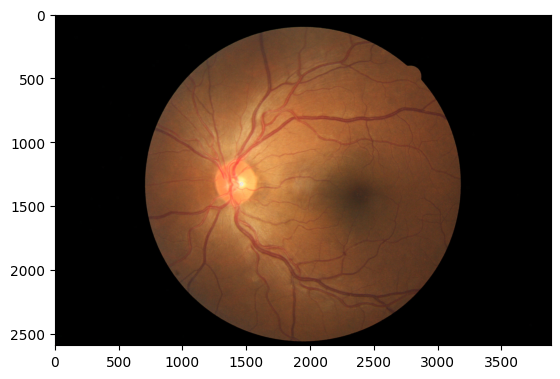

In [159]:
# Taking a matrix of size 5 as the kernel 
kernel = np.ones((3, 3), np.uint8) 
  
# The first parameter is the original image, 
# kernel is the matrix with which image is 
# convolved and third parameter is the number 
# of iterations, which will determine how much 
# you want to erode/dilate a given image. 
img_erosion = cv.erode(image, kernel, iterations=1) 
img_dilation = cv.dilate(image, kernel, iterations=1) 

#showImage(img_erosion)
showImage(img_dilation)

In [160]:
import csv

def read_csv_file(file_path):
    data = []
    with open(file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        for row in csv_reader:
            data.append(row)
    return data

# Example usage
file_path =  data_path + "optic_disc_centres.csv"# Replace 'example.csv' with the path to your CSV file
csv_data = read_csv_file(file_path)
print(csv_data)


[['image', 'x', 'y'], ['02_test.tif', '458', '275'], ['04_test.tif', '361', '275'], ['06_test.tif', '461', '268'], ['08_test.tif', '485', '277'], ['10_left.jpeg', '2439', '1697'], ['10_right.jpeg', '2985', '1562'], ['10_test.tif', '468', '278'], ['12_test.tif', '82', '257'], ['13_left.jpeg', '504', '832'], ['13_right.jpeg', '2119', '852'], ['13_test.tif', '486', '268'], ['14_test.tif', '479', '275'], ['15_test.tif', '193', '282'], ['16_test.tif', '479', '258'], ['17_left.jpeg', '1396', '1322'], ['17_test.tif', '467', '267'], ['18_test.tif', '471', '262'], ['19_left.jpeg', '1445', '1176'], ['19_right.jpeg', '2456', '1269'], ['19_test.tif', '486', '275'], ['1ffa92e4-8d87-11e8-9daf-6045cb817f5b..JPG', '541', '1530'], ['1ffa92fb-8d87-11e8-9daf-6045cb817f5b..JPG', '2620', '1343'], ['1ffa9309-8d87-11e8-9daf-6045cb817f5b..JPG', '609', '1167'], ['1ffa9523-8d87-11e8-9daf-6045cb817f5b..JPG', '652', '1070'], ['1ffa952f-8d87-11e8-9daf-6045cb817f5b..JPG', '2523', '1246'], ['1ffa9555-8d87-11e8-9daf-

In [161]:
import cv2
import os

def read_images_in_folder(folder_path):
    image_files = []
    valid_image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif','.tif']  # Add more extensions if needed

    file_names = []
    for file_name in os.listdir(folder_path):
        if os.path.isfile(os.path.join(folder_path, file_name)):
            file_extension = os.path.splitext(file_name)[1].lower()
            if file_extension in valid_image_extensions:
                image_files.append(os.path.join(folder_path, file_name))
                file_names.append(file_name)

    images = []
    for image_file in image_files:
        image = image_file
        if image is not None:
            images.append(image)

    return images,file_names

# Example usage
folder_path = fundus_path  # Replace 'images_folder' with the path to your folder
images,file_names = read_images_in_folder(folder_path)
print(f"Number of images found: {len(images)}")
print(file_names)


Number of images found: 56
['29_training.tif', '1ffa92e4-8d87-11e8-9daf-6045cb817f5b..JPG', '22_right.jpeg', '1ffa9309-8d87-11e8-9daf-6045cb817f5b..JPG', '33_left.jpeg', '16_test.tif', '17_test.tif', '19_left.jpeg', '21_left.jpeg', '10_right.jpeg', '20_right.jpeg', '22_training.tif', '25_training.tif', '13_left.jpeg', '30_training.tif', '31_right.jpeg', '06_test.tif', '37_training.tif', '25_right.jpeg', '31_training.tif', '20_left.jpeg', '24_training.tif', '23_training.tif', '10_test.tif', '1ffa92fb-8d87-11e8-9daf-6045cb817f5b..JPG', '1ffa9555-8d87-11e8-9daf-6045cb817f5b..JPG', '02_test.tif', '25_left.jpeg', '31_left.jpeg', '33_training.tif', '34_training.tif', '10_left.jpeg', '1ffa952f-8d87-11e8-9daf-6045cb817f5b..JPG', '21_training.tif', '26_training.tif', '08_test.tif', '23_right.jpeg', '15_test.tif', '14_test.tif', '20_test.tif', '27_training.tif', '23_left.jpeg', '35_training.tif', '32_training.tif', '19_right.jpeg', '38_training.tif', '12_test.tif', '13_test.tif', '13_right.jpeg'